In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier


In [2]:
from config import DATA_DIR
import pandas as pd
from pathlib import Path


In [3]:
DATA_PATH = DATA_DIR / "raw" / "Protest_pg_ready.csv"
df = pd.read_csv(DATA_PATH, sep=";")


In [4]:
df.shape


(14973, 30)

In [5]:
df.columns


Index(['Protest ID #', 'Country name', 'COW Country Code', 'Year', 'Region',
       'Protest', 'what number protest is this for this country year?',
       'Start Day', 'Start Month', 'Start Year', 'End Day', 'End Month',
       'End Year', 'Protester Violence', 'Location of Protest',
       'Number of Participants in Protest',
       'Reported participation in protest', 'Protester Group Identity',
       'Primary Protester Demands [Demand 1]',
       'Primary Protester Demands [Demand 2]',
       'Primary Protester Demands [Demand 3]',
       'Primary Protester Demands [Demand 4]',
       'Primary State Response to protests [Response 1]',
       'Primary State Response to protests [Response 2?¾]',
       'Primary State Response to protests [Response 3]',
       'Primary State Response to protests [Response 4]',
       'Primary State Response to protests [Response 5]',
       'Primary State Response to protests [Response 6]',
       'Primary State Response to protests [Response 7]', 'N

In [6]:
response_cols = [c for c in df.columns if "Primary State Response" in c]

pd.Series(
    pd.unique(df[response_cols].values.ravel())
).dropna().sort_values()


7                  .
2       accomodation
4            arrests
8           beatings
3    crowd dispersal
0             ignore
6           killings
5          shootings
dtype: object

In [7]:
response_cols = [c for c in df.columns if "Primary State Response" in c]

repressive = {"arrests", "beatings", "killings", "shootings"}

df["target_repression"] = (
    df[response_cols]
    .apply(lambda r: any(v in repressive for v in r), axis=1)
    .astype(int)
)


In [8]:
df["target_repression"].value_counts(normalize=True)


target_repression
0    0.797836
1    0.202164
Name: proportion, dtype: float64

In [9]:
df["target_repression"].value_counts()



target_repression
0    11946
1     3027
Name: count, dtype: int64

In [10]:
df["Reported participation in protest"] \
    .dropna() \
    .astype(str) \
    .str.strip() \
    .value_counts() \
    .head(50)


Reported participation in protest
100s                 1193
1000s                1104
1000                  948
>50                   934
50+                   891
50                    818
100                   794
.                     525
10000                 384
200                   381
2000                  330
300                   277
100+                  269
500                   263
5000                  232
10000s                231
3000                  225
20000                 164
150                   128
4000                  124
400                   120
100000                108
hundreds               97
Thousands              96
15000                  91
30000                  88
> 50                   83
50000                  83
1500                   79
6000                   73
1000+                  73
7000                   64
dozens                 60
60                     58
8000                   57
>100                   57
700                    56
250 

In [11]:
import re
import numpy as np

def size_binner(x):
    if pd.isna(x):
        return 0

    s = str(x).lower().replace(",", "").strip()

    if s in {".", ""}:
        return 0

    if re.search(r"million", s) or re.search(r"\b[5-9]\d{4,}\b", s):
        return 6

    if re.search(r"tens of thousands|10000|15000|20000|25000|30000|40000", s):
        return 5

    if re.search(r"thousand|1000s|\b[1-9]\d{3}\b", s):
        return 4

    if re.search(r"hundred|100|200|300|400|500|600|700|800|900", s):
        return 3

    if re.search(r"\b50\b|>50|50\+", s):
        return 2

    if re.search(r"dozen|<50|few", s):
        return 1

    return 0

df["protest_size_bin"] = df["Reported participation in protest"].apply(size_binner)


In [12]:
df["protest_size_bin"].value_counts().sort_index()


protest_size_bin
0    2312
1      73
2    2740
3    4033
4    3897
5    1645
6     273
Name: count, dtype: int64

In [13]:
pd.crosstab(df["protest_size_bin"], df["target_repression"], normalize="index")


target_repression,0,1
protest_size_bin,,
0,0.933824,0.066176
1,0.863014,0.136986
2,0.753650,0.246350
3,0.746095,0.253905
4,0.783423,0.216577
5,0.828571,0.171429
6,0.857143,0.142857


In [14]:
demand_cols = [c for c in df.columns if "Demand" in c]
demand_cols


['Primary Protester Demands [Demand 1]',
 'Primary Protester Demands [Demand 2]',
 'Primary Protester Demands [Demand 3]',
 'Primary Protester Demands [Demand 4]']

In [15]:
for col in demand_cols:
    print("=" * 60)
    print(col)
    print(df[col].value_counts(dropna=False).head(10))


Primary Protester Demands [Demand 1]
Primary Protester Demands [Demand 1]
political behavior, process    8544
NaN                            1757
labor wage dispute             1560
price increases, tax policy     996
removal of politician           794
police brutality                669
land farm issue                 341
social restrictions             312
Name: count, dtype: int64
Primary Protester Demands [Demand 2]
Primary Protester Demands [Demand 2]
NaN                            12673
political behavior, process      781
removal of politician            499
labor wage dispute               402
price increases, tax policy      187
police brutality                 169
social restrictions              169
land farm issue                   93
Name: count, dtype: int64
Primary Protester Demands [Demand 3]
Primary Protester Demands [Demand 3]
NaN                            14668
price increases, tax policy      109
labor wage dispute                60
removal of politician          

In [16]:
df[demand_cols].describe(include="all").T


,count,unique,top,freq
Primary Protester Demands [Demand 1],13216,7,"political behavior, process",8544
Primary Protester Demands [Demand 2],2300,7,"political behavior, process",781
Primary Protester Demands [Demand 3],305,7,"price increases, tax policy",109
Primary Protester Demands [Demand 4],21,6,police brutality,7


In [17]:
def normalize(x):
    if pd.isna(x):
        return ""
    return x.strip().lower()

political_kw = [
    "political",
    "removal",
    "social restriction"
]

economic_kw = [
    "labor",
    "wage",
    "price",
    "tax",
    "land",
    "farm"
]

police_kw = [
    "police"
]

def has_kw(row, keywords):
    values = [normalize(row[c]) for c in demand_cols]
    return any(any(kw in v for kw in keywords) for v in values)

df["has_political_demand"] = df.apply(has_kw, axis=1, keywords=political_kw).astype(int)
df["has_economic_demand"] = df.apply(has_kw, axis=1, keywords=economic_kw).astype(int)
df["has_police_demand"] = df.apply(has_kw, axis=1, keywords=police_kw).astype(int)

df["political_only"] = (
    (df["has_political_demand"] == 1) &
    (df["has_economic_demand"] == 0) &
    (df["has_police_demand"] == 0)
).astype(int)


In [18]:
df[[
    "has_political_demand",
    "has_economic_demand",
    "has_police_demand",
    "political_only"
]].mean()


has_political_demand    0.687705
has_economic_demand     0.235691
has_police_demand       0.058305
political_only          0.592333
dtype: float64

In [19]:
def norm(x):
    if pd.isna(x):
        return ""
    return x.lower()

s = df["Protester Group Identity"].fillna("").str.lower()

df["has_student_group"] = s.str.contains(
    "student|university|youth"
).astype(int)

df["has_labor_group"] = s.str.contains(
    "worker|labor|union|farmer|trader|taxi|fisherman"
).astype(int)

df["has_political_group"] = s.str.contains(
    "opposition|party|movement|anti-government|pro-reform"
).astype(int)

df["has_professional_group"] = s.str.contains(
    "teacher|journalist|lawyer|doctor"
).astype(int)

df["has_women_group"] = s.str.contains(
    "women|ladies|women's"
).astype(int)

df["has_security_group"] = s.str.contains(
    "soldier|prisoner"
).astype(int)

df["num_groups"] = (
    df[[
        "has_student_group",
        "has_labor_group",
        "has_political_group",
        "has_professional_group",
        "has_women_group",
        "has_security_group"
    ]].sum(axis=1)
)


In [20]:
df[[
    "has_student_group",
    "has_labor_group",
    "has_political_group",
    "has_professional_group",
    "has_women_group",
    "has_security_group",
    "num_groups"
]].mean()


has_student_group         0.111601
has_labor_group           0.148067
has_political_group       0.094170
has_professional_group    0.033460
has_women_group           0.020370
has_security_group        0.011087
num_groups                0.418754
dtype: float64

In [21]:
pd.crosstab(
    df["has_political_group"],
    df["target_repression"],
    normalize="index"
)


target_repression,0,1
has_political_group,,
0,0.809408,0.190592
1,0.686525,0.313475


In [22]:
df["decade"] = (df["Year"] // 10) * 10


In [23]:
df["decade"].head()


0    1990
1    1990
2    1990
3    1990
4    1990
Name: decade, dtype: int64

In [24]:
df = df.rename(columns={"protest_size_bin": "participants_bin"})


In [25]:
y = df["target_repression"]


In [26]:
FEATURES = [
    "participants_bin",
    "num_demands",
    "has_political_demand",
    "has_economic_demand",
    "has_police_demand",
    "political_only",

    "has_student_group",
    "has_labor_group",
    "has_political_group",
    "has_professional_group",
    "has_women_group",
    "has_security_group",
    "num_groups",

    "decade"
]


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report

X = df[FEATURES]
y = df["target_repression"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=40,
    random_state=42
)

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, probs))


KeyError: "['num_demands'] not in index"

In [ ]:
threshold = 0.35
pred = (probs >= threshold).astype(int)

print(classification_report(y_test, pred))


              precision    recall  f1-score   support

           0       0.82      0.92      0.87      2987
           1       0.42      0.23      0.30       757

    accuracy                           0.78      3744
   macro avg       0.62      0.57      0.58      3744
weighted avg       0.74      0.78      0.75      3744



In [ ]:
import pandas as pd

imp = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

imp


num_demands               0.412469
has_student_group         0.186632
has_police_demand         0.118281
participants_bin          0.082618
has_political_group       0.076206
has_labor_group           0.056636
has_professional_group    0.017932
decade                    0.017650
has_women_group           0.015034
political_only            0.010327
has_political_demand      0.003463
num_groups                0.002170
has_economic_demand       0.000454
has_security_group        0.000128
dtype: float64

In [ ]:
import numpy as np

for t in [0.25, 0.3, 0.35, 0.4]:
    pred = (probs >= t).astype(int)
    print("Threshold:", t)
    print(classification_report(y_test, pred))


Threshold: 0.25
              precision    recall  f1-score   support

           0       0.85      0.79      0.82      2987
           1       0.36      0.47      0.40       757

    accuracy                           0.72      3744
   macro avg       0.60      0.63      0.61      3744
weighted avg       0.75      0.72      0.73      3744

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      2987
           1       0.39      0.34      0.36       757

    accuracy                           0.76      3744
   macro avg       0.61      0.60      0.61      3744
weighted avg       0.75      0.76      0.75      3744

Threshold: 0.35
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      2987
           1       0.42      0.23      0.30       757

    accuracy                           0.78      3744
   macro avg       0.62      0.57      0.58      3744
weighted avg       0.74    

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

clf.fit(X_train, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# 1) probability
y_proba = clf.predict_proba(X_test)[:, 1]

# 2) feature importance
fi = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

fi["importance_pct"] = 100 * fi["importance"] / fi["importance"].sum()

print("=== Feature Importance ===")
print(fi)

# 3) main threshold (official)
threshold = 0.25
y_pred_025 = (y_proba >= threshold).astype(int)

print("\n=== Threshold 0.25 (MAIN) ===")
print(classification_report(y_test, y_pred_025))

# 4) sanity check thresholds
for t in [0.20, 0.15]:
    y_pred = (y_proba >= t).astype(int)
    print(f"\n=== Threshold {t} (sanity check) ===")
    print(classification_report(y_test, y_pred))


=== Feature Importance ===
                   feature  importance  importance_pct
1              num_demands    0.401163       40.116281
6        has_student_group    0.156159       15.615878
0         participants_bin    0.107158       10.715767
4        has_police_demand    0.101869       10.186950
8      has_political_group    0.059388        5.938837
7          has_labor_group    0.055101        5.510124
13                  decade    0.036363        3.636255
9   has_professional_group    0.020125        2.012514
12              num_groups    0.016977        1.697683
10         has_women_group    0.016557        1.655694
2     has_political_demand    0.013589        1.358872
5           political_only    0.009240        0.924040
3      has_economic_demand    0.003519        0.351869
11      has_security_group    0.002792        0.279237

=== Threshold 0.25 (MAIN) ===
              precision    recall  f1-score   support

           0       0.85      0.78      0.82      2987
        

In [ ]:
for t in [0.20, 0.15]:
    y_pred = (y_proba >= t).astype(int)
    print(f"\n=== Threshold {t} (sanity check) ===")
    print(classification_report(y_test, y_pred))



=== Threshold 0.2 (sanity check) ===
              precision    recall  f1-score   support

           0       0.88      0.55      0.68      2987
           1       0.28      0.70      0.40       757

    accuracy                           0.58      3744
   macro avg       0.58      0.63      0.54      3744
weighted avg       0.76      0.58      0.62      3744


=== Threshold 0.15 (sanity check) ===
              precision    recall  f1-score   support

           0       0.93      0.34      0.50      2987
           1       0.26      0.90      0.40       757

    accuracy                           0.45      3744
   macro avg       0.59      0.62      0.45      3744
weighted avg       0.79      0.45      0.48      3744



In [ ]:
import joblib

joblib.dump(clf, "L1_state_repression_model.pkl")


['L1_state_repression_model.pkl']

In [ ]:
L1_METADATA = {
    "model_name": "State Repression Model (L1)",
    "model_type": "GradientBoostingClassifier",
    "features": list(X_train.columns),
    "n_features": X_train.shape[1],
    "threshold_main": 0.25,
    "notes": "Event-level behavioral model. Output used as probability, not label.",
    "frozen_on": "2026-03-20"
}


In [ ]:
FEATURES_L1 = [
    "participants_bin",
    "num_demands",
    "has_political_demand",
    "has_economic_demand",
    "has_police_demand",
    "political_only",
    "has_student_group",
    "has_labor_group",
    "has_political_group",
    "has_professional_group",
    "has_women_group",
    "has_security_group",
    "num_groups",
    "decade"
]


In [ ]:
X_full = df[FEATURES_L1]


In [ ]:
print(X_full.shape)
print(X_full.isnull().sum())


(14973, 14)
participants_bin          0
num_demands               0
has_political_demand      0
has_economic_demand       0
has_police_demand         0
political_only            0
has_student_group         0
has_labor_group           0
has_political_group       0
has_professional_group    0
has_women_group           0
has_security_group        0
num_groups                0
decade                    0
dtype: int64


In [ ]:
df["P_repression"] = clf.predict_proba(X_full)[:, 1]


In [ ]:
print(df.columns.tolist())


['Protest ID #', 'Country name', 'COW Country Code', 'Year', 'Region', 'Protest', 'what number protest is this for this country year?', 'Start Day', 'Start Month', 'Start Year', 'End Day', 'End Month', 'End Year', 'Protester Violence', 'Location of Protest', 'Number of Participants in Protest', 'Reported participation in protest', 'Protester Group Identity', 'Primary Protester Demands [Demand 1]', 'Primary Protester Demands [Demand 2]', 'Primary Protester Demands [Demand 3]', 'Primary Protester Demands [Demand 4]', 'Primary State Response to protests [Response 1]', 'Primary State Response to protests [Response 2?¾]', 'Primary State Response to protests [Response 3]', 'Primary State Response to protests [Response 4]', 'Primary State Response to protests [Response 5]', 'Primary State Response to protests [Response 6]', 'Primary State Response to protests [Response 7]', 'Notes', 'target_repression', 'participants_bin', 'num_demands', 'has_political_demand', 'has_economic_demand', 'has_pol

We freeze the event-level repression model after validating its stability across multiple probability thresholds. The model is not used for classification, but as a behavioral mapping from protest characteristics to the probability of state repression.

## Behavioral Profile Aggregation

In [ ]:
import numpy as np
import pandas as pd

THRESHOLD = 0.25

df_L2 = (
    df
    .groupby(["Country name", "Year"])
    .apply(lambda x: pd.Series({
        # Volume
        "n_events": len(x),

        # Core repression behavior
        "mean_repression": x["P_repression"].mean(),
        "std_repression": x["P_repression"].std(),

        # Reporting threshold (descriptive only)
        "repression_rate": (x["P_repression"] >= THRESHOLD).mean(),

        # Sensitivities
        "size_sensitivity": np.corrcoef(
            x["participants_bin"], x["P_repression"]
        )[0, 1] if x["participants_bin"].nunique() > 1 else 0,

        "political_demand_sensitivity": (
            x.loc[x["has_political_demand"] == 1, "P_repression"].mean()
            - x.loc[x["has_political_demand"] == 0, "P_repression"].mean()
        ) if x["has_political_demand"].nunique() > 1 else 0,

        "student_sensitivity": (
            x.loc[x["has_student_group"] == 1, "P_repression"].mean()
            - x.loc[x["has_student_group"] == 0, "P_repression"].mean()
        ) if x["has_student_group"].nunique() > 1 else 0
    }))
    .reset_index()
)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_10340\103490800.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


In [ ]:
print(df_L2.shape)
df_L2.head()


(4399, 9)


,Country name,Year,n_events,mean_repression,std_repression,repression_rate,size_sensitivity,political_demand_sensitivity,student_sensitivity
0,Afghanistan,1990,1.0,0.003642,NaN,0.0,0.0,0.0,0.0
1,Afghanistan,1991,1.0,0.361923,NaN,1.0,0.0,0.0,0.0
2,Afghanistan,1992,1.0,0.003642,NaN,0.0,0.0,0.0,0.0
3,Afghanistan,1993,1.0,0.003642,NaN,0.0,0.0,0.0,0.0
4,Afghanistan,1994,1.0,0.003642,NaN,0.0,0.0,0.0,0.0


In [ ]:
import pandas as pd

df = pd.read_csv("Protest_pg_ready.csv", sep=";")

# ----------------------
# Merge Demands
# ----------------------
demand_cols = [
    "Primary Protester Demands [Demand 1]",
    "Primary Protester Demands [Demand 2]",
    "Primary Protester Demands [Demand 3]",
    "Primary Protester Demands [Demand 4]"
]

df["All_Demands"] = df[demand_cols].apply(
    lambda row: [d for d in row if pd.notna(d)],
    axis=1
)

# ----------------------
# Merge Responses
# ----------------------
response_cols = [
    "Primary State Response to protests [Response 1]",
    "Primary State Response to protests [Response 2?¾]",
    "Primary State Response to protests [Response 3]",
    "Primary State Response to protests [Response 4]",
    "Primary State Response to protests [Response 5]",
    "Primary State Response to protests [Response 6]",
    "Primary State Response to protests [Response 7]"
]

df["All_Responses"] = df[response_cols].apply(
    lambda row: [r for r in row if pd.notna(r)],
    axis=1
)

print(df[["Country name", "Year", "Protester Group Identity", "All_Demands", "All_Responses"]].head(5))


  Country name  Year      Protester Group Identity  \
0       Canada  1990                   unspecified   
1       Canada  1990                   unspecified   
2       Canada  1990  (separatist) Parti Quebecois   
3       Canada  1990                Mohawk Indians   
4       Canada  1990               local residents   

                                         All_Demands  \
0  [political behavior, process, labor wage dispute]   
1                      [political behavior, process]   
2                      [political behavior, process]   
3                                  [land farm issue]   
4                      [political behavior, process]   

                              All_Responses  
0                                  [ignore]  
1                                  [ignore]  
2                                  [ignore]  
3                            [accomodation]  
4  [crowd dispersal, arrests, accomodation]  


In [ ]:
import pandas as pd

df = pd.read_csv("Protest_pg_ready.csv", sep=";")

response_cols = [
    "Primary State Response to protests [Response 1]",
    "Primary State Response to protests [Response 2?¾]",
    "Primary State Response to protests [Response 3]",
    "Primary State Response to protests [Response 4]",
    "Primary State Response to protests [Response 5]",
    "Primary State Response to protests [Response 6]",
    "Primary State Response to protests [Response 7]"
]

# Merge responses
df["All_Responses"] = df[response_cols].apply(
    lambda row: [r for r in row if pd.notna(r)],
    axis=1
)

# Severity mapping based on actual dataset
RESPONSE_SEVERITY = {
    ".": 0,
    "ignore": 0,
    "accomodation": 1,
    "crowd dispersal": 2,
    "arrests": 3,
    "beatings": 4,
    "shootings": 5,
    "killings": 6
}

def compute_rsi(responses):
    scores = [RESPONSE_SEVERITY.get(r, 0) for r in responses]
    return max(scores) if scores else 0

df["RSI"] = df["All_Responses"].apply(compute_rsi)

print(df[["Country name","Year","All_Responses","RSI"]].head(10))
print("\nRSI distribution:")
print(df["RSI"].value_counts().sort_index())


  Country name  Year                             All_Responses  RSI
0       Canada  1990                                  [ignore]    0
1       Canada  1990                                  [ignore]    0
2       Canada  1990                                  [ignore]    0
3       Canada  1990                            [accomodation]    1
4       Canada  1990  [crowd dispersal, arrests, accomodation]    3
5       Canada  1990              [crowd dispersal, shootings]    5
6       Canada  1991                                  [ignore]    0
7       Canada  1991                                  [ignore]    0
8       Canada  1992                                 [arrests]    3
9       Canada  1993                                  [ignore]    0

RSI distribution:
RSI
0    8744
1     902
2    2300
3    1344
4     598
5     385
6     700
Name: count, dtype: int64


In [ ]:
ACTOR_KEYWORDS = {
    "student_group": [
        "student", "students", "university", "college", "school", "pupil"
    ],
    "labor_group": [
        "worker", "workers", "labor", "labour", "union", "miners", "factory",
        "oil", "steel", "dock", "transport"
    ],
    "professional_group": [
        "teacher", "teachers", "journalist", "journalists",
        "lawyer", "lawyers", "doctor", "doctors", "nurse", "nurses"
    ],
    "political_group": [
        "political", "party", "opposition", "activist", "activists",
        "movement", "campaign"
    ],
    "identity_group": [
        "ethnic", "tribe", "tribal", "minority", "religious",
        "sect", "indigenous"
    ],
    "mass_public": [
        "public", "citizens", "residents", "people", "community",
        "population", "locals"
    ]
}


In [ ]:
def classify_actor(actor_str):
    if pd.isna(actor_str):
        return "other"
    s = actor_str.lower()
    for actor_type, keywords in ACTOR_KEYWORDS.items():
        if any(k in s for k in keywords):
            return actor_type
    return "other"

df["Actor_Type"] = df["Protester Group Identity"].apply(classify_actor)


In [ ]:
def classify_actor(actor_str):
    if pd.isna(actor_str):
        return "other"
    s = actor_str.lower()
    for actor_type, keywords in ACTOR_KEYWORDS.items():
        if any(k in s for k in keywords):
            return actor_type
    return "other"


In [ ]:
df["Actor_Type"] = df["Protester Group Identity"].apply(classify_actor)


In [ ]:
print(df["Actor_Type"].value_counts())


Actor_Type
other                 9252
labor_group           1609
student_group         1490
political_group       1402
mass_public            728
professional_group     327
identity_group         165
Name: count, dtype: int64


In [ ]:
demand_cols = [
    "Primary Protester Demands [Demand 1]",
    "Primary Protester Demands [Demand 2]",
    "Primary Protester Demands [Demand 3]",
    "Primary Protester Demands [Demand 4]"
]


In [ ]:
df["All_Demands"] = df[demand_cols].apply(
    lambda row: [d for d in row if pd.notna(d) and d != "."],
    axis=1
)


In [ ]:
df["All_Demands"].head(10)


0    [political behavior, process, labor wage dispute]
1                        [political behavior, process]
2                        [political behavior, process]
3                                    [land farm issue]
4                        [political behavior, process]
5                                   [police brutality]
6                                 [labor wage dispute]
7                                 [labor wage dispute]
8                                   [police brutality]
9                        [political behavior, process]
Name: All_Demands, dtype: object

In [ ]:
df["All_Demands"].explode().value_counts().head(30)


All_Demands
political behavior, process    9361
labor wage dispute             2024
removal of politician          1348
price increases, tax policy    1294
police brutality                873
social restrictions             494
land farm issue                 448
Name: count, dtype: int64

In [ ]:
DEMAND_MAP = {
    "political behavior, process": "political_demand",
    "removal of politician": "political_demand",

    "labor wage dispute": "economic_demand",
    "price increases, tax policy": "economic_demand",

    "police brutality": "freedom_demand",
    "social restrictions": "freedom_demand",

    "land farm issue": "identity_demand"
}


In [ ]:
def map_demand_type(demand_list):
    if not demand_list:
        return "no_demand"

    mapped = [DEMAND_MAP.get(d, "other_demand") for d in demand_list]

    priority = [
        "political_demand",
        "freedom_demand",
        "economic_demand",
        "identity_demand",
        "other_demand"
    ]

    for p in priority:
        if p in mapped:
            return p

    return "other_demand"


In [ ]:
df["Demand_Type"] = df["All_Demands"].apply(map_demand_type)


In [ ]:
df["Demand_Type"].value_counts()


Demand_Type
political_demand    10020
economic_demand      2066
no_demand            1757
freedom_demand        874
identity_demand       256
Name: count, dtype: int64

In [ ]:
matrix = (
    df
    .groupby(["Actor_Type", "Demand_Type"])["RSI"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .sort_values("mean", ascending=False)
)


In [ ]:
matrix.head(20)


,Actor_Type,Demand_Type,count,mean,median
28,student_group,freedom_demand,110,2.345455,2.0
10,mass_public,freedom_demand,77,2.103896,2.0
29,student_group,identity_demand,12,2.083333,1.5
27,student_group,economic_demand,229,2.021834,2.0
9,mass_public,economic_demand,60,2.000000,1.5
3,identity_group,political_demand,127,1.866142,2.0
14,other,freedom_demand,505,1.863366,2.0
20,political_group,identity_demand,11,1.818182,3.0
2,identity_group,identity_demand,10,1.800000,1.5
30,student_group,political_demand,1139,1.796313,2.0


In [ ]:
df["Demand_Type"].value_counts()


Demand_Type
political_demand    10020
economic_demand      2066
no_demand            1757
freedom_demand        874
identity_demand       256
Name: count, dtype: int64

In [ ]:
matrix_clean = matrix[matrix["Demand_Type"] != "no_demand"]


In [ ]:
matrix_clean["RSI_z"] = (
    matrix_clean["mean"] - matrix_clean["mean"].mean()
) / matrix_clean["mean"].std()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1276\2472796039.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matrix_clean["RSI_z"] = (


In [ ]:
country_profile = (
    df[df["Demand_Type"] != "no_demand"]
    .groupby(["Country name", "Demand_Type"])["RSI"]
    .mean()
    .unstack()
)


In [ ]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(country_profile.fillna(0))


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
country_profile["Regime_Type_Latent"] = kmeans.fit_predict(X)


In [ ]:
memory = (
    df[df["Demand_Type"] != "no_demand"]
    .groupby(["Country name", "Demand_Type"])
    .agg(
        mean_RSI=("RSI", "mean"),
        high_repression_rate=("RSI", lambda x: (x >= 4).mean()),
        event_count=("RSI", "count")
    )
    .reset_index()
)


  # ===============================
  # Final Repression Model Analysis
  # ===============================


In [ ]:
# ===============================
# Step 0: Final Repression Model
# Load Data & Define Variables
# ===============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# reproducibility
RANDOM_STATE = 42


In [ ]:
# ===============================
# Step 1: Define response mapping
# ===============================

response_mapping = {
    "ignore": 0,
    "accomodation": 0,
    "crowd dispersal": 0,   # conservative choice
    "arrests": 1,
    "beatings": 1,
    "shootings": 1,
    "killings": 1
}


In [ ]:
# ===============================
# Step 32: Final target
# ===============================

df["target_repression"] = df["target_repression_r1"].fillna(0).astype(int)

df["target_repression"].value_counts(normalize=True)


target_repression
0    0.87611
1    0.12389
Name: proportion, dtype: float64

State repression is operationalized using categorical state response codes, where arrests, beatings, shootings, and killings are classified as repressive actions.

In [ ]:
# ===============================
# Inspect Protester Group Identity
# ===============================

df["Protester Group Identity"].dropna().value_counts().head(20)


Protester Group Identity
protesters                                                           1188
students                                                              465
unspecified                                                           224
workers                                                               211
farmers                                                               182
Students                                                              140
demonstrators                                                         121
university students                                                   119
residents                                                             117
opposition supporters                                                 112
Protesters                                                             75
teachers                                                               71
women                                                                  62
People       

In [ ]:
# Clean identity column
df["group_identity_clean"] = (
    df["Protester Group Identity"]
    .fillna("")
    .str.lower()
    .str.strip()
)


In [ ]:
# STUDENTS
df["has_student_group"] = df["group_identity_clean"].str.contains(
    r"\bstudent|university\b", regex=True
).astype(int)

# LABOR / WORKERS
df["has_labor_group"] = df["group_identity_clean"].str.contains(
    r"\bworker", regex=True
).astype(int)

# FARMERS
df["has_farmer_group"] = df["group_identity_clean"].str.contains(
    r"\bfarmer", regex=True
).astype(int)

# WOMEN
df["has_women_group"] = df["group_identity_clean"].str.contains(
    r"\bwomen\b", regex=True
).astype(int)

# TEACHERS
df["has_teacher_group"] = df["group_identity_clean"].str.contains(
    r"\bteacher\b", regex=True
).astype(int)

# YOUTH
df["has_youth_group"] = df["group_identity_clean"].str.contains(
    r"\byouth", regex=True
).astype(int)

# POLITICAL / OPPOSITION
df["has_political_group"] = df["group_identity_clean"].str.contains(
    r"opposition|party|supporter", regex=True
).astype(int)

# PEGIDA / NATIONALIST (اختیاری)
df["has_nationalist_group"] = df["group_identity_clean"].str.contains(
    r"pegida", regex=True
).astype(int)


In [ ]:
group_cols = [
    "has_student_group",
    "has_labor_group",
    "has_farmer_group",
    "has_women_group",
    "has_teacher_group",
    "has_youth_group",
    "has_political_group",
    "has_nationalist_group"
]

df["num_groups"] = df[group_cols].sum(axis=1)


In [ ]:
df["decade"] = (df["Year"] // 10) * 10


In [ ]:
df[group_cols + ["num_groups", "decade"]].describe()


,has_student_group,has_labor_group,has_farmer_group,has_women_group,has_teacher_group,has_youth_group,has_political_group,has_nationalist_group,num_groups,decade
count,14973.000000,14973.000000,14973.000000,14973.000000,14973.000000,14973.000000,14973.000000,14973.000000,14973.000000,14973.000000
mean,0.095505,0.070193,0.028384,0.014025,0.000200,0.017632,0.102518,0.006144,0.334602,2000.285180
std,0.293921,0.255481,0.166074,0.117599,0.014154,0.131613,0.303338,0.078148,0.515822,8.197413
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1990.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1990.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2000.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2010.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,2010.000000


In [ ]:
response_cols = [
    "Primary State Response to protests [Response 1]",
    "Primary State Response to protests [Response 2]",
    "Primary State Response to protests [Response 3]",
    "Primary State Response to protests [Response 4]",
    "Primary State Response to protests [Response 5]",
    "Primary State Response to protests [Response 6]",
    "Primary State Response to protests [Response 7]"
]


In [ ]:
# ===============================
# Rebuild target_repression
# ===============================

def is_repression(response):
    if pd.isna(response):
        return 0
    response = response.lower().strip()
    return int(response in [
        "arrests",
        "beatings",
        "shootings",
        "killings"
    ])

df["target_repression"] = df["Primary State Response to protests [Response 1]"].apply(is_repression)


In [ ]:
REPRESSIVE_ACTIONS = {
    "arrests",
    "beatings",
    "shootings",
    "killings"
}


In [ ]:
def is_repression_row(row):
    for col in response_cols:
        val = row.get(col)
        if pd.isna(val):
            continue
        if val.lower().strip() in REPRESSIVE_ACTIONS:
            return 1
    return 0

df["target_repression"] = df.apply(is_repression_row, axis=1)


In [ ]:
df["target_repression"].value_counts(normalize=True)


target_repression
0    0.850264
1    0.149736
Name: proportion, dtype: float64

In [ ]:
pd.crosstab(df["target_repression"], df["has_student_group"], normalize="index")


has_student_group,0,1
target_repression,,
0,0.902443,0.097557
1,0.808653,0.191347


In [ ]:
df = df.rename(columns={
    "Country name": "country"
})


In [ ]:
features = [
    "has_student_group",
    "has_political_group",
    "has_labor_group",
    "has_women_group",
    "num_groups",
    "decade",
    "country"
]

target = "target_repression"


“Latent regime type was excluded from the repression model due to substantial missingness (63%) and because it was constructed solely from political protest events, making it conceptually misaligned with the broader universe of protest types analyzed in this model.”

In [ ]:
X = df[features]
y = df[target]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier


In [ ]:
categorical_features = ["country"]
numeric_features = [
    "has_student_group",
    "has_political_group",
    "has_labor_group",
    "has_women_group",
    "num_groups",
    "decade"
]


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)


In [ ]:
model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)


In [ ]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)


In [ ]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]


In [ ]:
print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.854     0.998     0.920      6349
           1      0.778     0.037     0.071      1128

    accuracy                          0.853      7477
   macro avg      0.816     0.518     0.496      7477
weighted avg      0.842     0.853     0.792      7477



In [ ]:
roc_auc_score(y_test, y_prob)


0.7448533666439905

In [ ]:
y_test.mean()


np.float64(0.1508626454460345)

In [ ]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

r = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

imp_df = pd.DataFrame({
    "feature": X_test.columns,   # ✅ ویژگی‌های خام
    "importance": r.importances_mean
}).sort_values("importance", ascending=False)

imp_df


,feature,importance
6,country,0.188929
0,has_student_group,0.022438
5,decade,0.022379
2,has_labor_group,0.003536
1,has_political_group,0.002418
4,num_groups,0.001014
3,has_women_group,0.000029


Permutation importance analysis shows that country-level fixed effects account for most predictive power, while protest composition—especially student participation—and temporal context are the most influential protest-level predictors of repression.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12484\3751779467.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


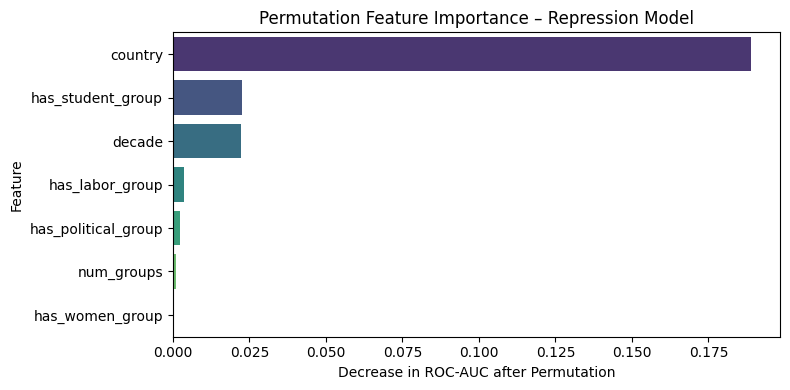

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

sns.barplot(
    data=imp_df,
    x="importance",
    y="feature",
    palette="viridis"
)

plt.title("Permutation Feature Importance – Repression Model", fontsize=12)
plt.xlabel("Decrease in ROC-AUC after Permutation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


Overall, state repression is driven primarily by country-level structural factors and temporal context, while protester composition—particularly student participation—plays a secondary but consistent role in shaping repression decisions.

